# Phase 7: Does the result hold across architectures and unseen corruptions?

CPU only, Internet off. **Attach BOTH notebook outputs:** `phase-1-sep-14` and
`phase-6-sep-15`.

Runs the Phase 3 to 5 analysis over two architectures and two corruption sets
(the 15 standard, and the 4 held out ones no design decision touched).

In [1]:
import glob, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.stats import beta

F1=[h for h in glob.glob("/kaggle/input/**/logits.npz",recursive=True)][0]
F2=[h for h in glob.glob("/kaggle/input/**/logits2.npz",recursive=True)][0]
d1,d2=np.load(F1),np.load(F2)
SEEDS=[0,1,2]; TG=0.05; TOL=1e-9
STD15=["gaussian_noise","shot_noise","impulse_noise","defocus_blur","glass_blur",
       "motion_blur","zoom_blur","snow","frost","fog","brightness","contrast",
       "elastic_transform","pixelate","jpeg_compression"]
EXTRA=["speckle_noise","gaussian_blur","spatter","saturate"]

def softmax(z,T=1.0):
    z=z.astype(np.float64)/T; z-=z.max(1,keepdims=True); e=np.exp(z); return e/e.sum(1,keepdims=True)
def nll(p,y): return -np.log(np.clip(p[np.arange(len(y)),y],1e-12,None)).mean()
def ep(m,T): return np.mean([softmax(x,T) for x in m],0)

def raw(arch,corr,sev):
    if arch=="wrn": return [d2[f"wrn_{corr}_{sev}_{s}"] for s in SEEDS]
    return [(d1 if corr in STD15 else d2)[(f"{corr}_{sev}_{s}" if corr in STD15
             else f"res_{corr}_{sev}_{s}")] for s in SEEDS]
def raw_val(arch):  return [(d2[f"wrn_val_{s}"]  if arch=="wrn" else d1[f"val_{s}"])  for s in SEEDS]
def raw_test(arch): return [(d2[f"wrn_test_{s}"] if arch=="wrn" else d1[f"test_{s}"]) for s in SEEDS]

Y_VAL,Y_TEST,Y_CORR=d1["y_val"],d1["y_test"],d1["y_corr"]
TEMP,PV={},{}
for a in ("res","wrn"):
    TEMP[a]=minimize_scalar(lambda t,a=a: nll(ep(raw_val(a),t),Y_VAL),
                            bounds=(.5,10),method="bounded").x
    PV[a]=ep(raw_val(a),TEMP[a])
    print(f"{a}: T={TEMP[a]:.3f}  clean acc={(ep(raw_test(a),TEMP[a]).argmax(1)==Y_TEST).mean()*100:.1f}%")

P={}
for a in ("res","wrn"):
    P[(a,"test",0)]=(ep(raw_test(a),TEMP[a]),Y_TEST)
    for corr in STD15+EXTRA:
        for sev in range(1,6):
            P[(a,corr,sev)]=(ep(raw(a,corr,sev),TEMP[a]),Y_CORR)
print(len(P),"cells")

res: T=1.242  clean acc=95.3%
wrn: T=1.219  clean acc=95.0%
192 cells


## 1. Selectors (same as Phase 4)

In [2]:
def rc(pr,y,thr):
    cf,pd_=pr.max(1),pr.argmax(1); a=cf>=thr
    if a.sum()==0: return np.nan,0.0
    return 1-(pd_[a]==y[a]).mean(), a.mean()
def _pick(cf,est,t):
    ok=np.where(est<=t+TOL)[0]
    return 1.0 if len(ok)==0 else np.sort(cf)[::-1][ok[-1]]
def thr_oracle(pr,y,t):
    cf=pr.max(1); o=np.argsort(-cf)
    return _pick(cf,1-np.cumsum(pr.argmax(1)[o]==y[o])/np.arange(1,len(o)+1),t)
def cov_target(pr,y,t):
    cf=pr.max(1); o=np.argsort(-cf)
    r=1-np.cumsum(pr.argmax(1)[o]==y[o])/np.arange(1,len(o)+1)
    ok=np.where(r<=t+TOL)[0]
    return 0.0 if len(ok)==0 else (ok[-1]+1)/len(o)
def thr_meanconf(pr,t):
    cf=pr.max(1); o=np.argsort(-cf)
    return _pick(cf,np.cumsum(1-cf[o])/np.arange(1,len(o)+1),t)
NE=lambda pr:(pr*np.log(np.clip(pr,1e-12,None))).sum(1)
CUT,THRC={},{}
for a in ("res","wrn"):
    cv=PV[a].argmax(1)==Y_VAL
    CUT[a]=(np.quantile(PV[a].max(1),1-cv.mean()), np.quantile(NE(PV[a]),1-cv.mean()))
    THRC[a]=thr_oracle(PV[a],Y_VAL,TG)
def thr_atc(a,pr,t,mode):
    cf=pr.max(1); s=cf if mode=="MC" else NE(pr); cut=CUT[a][0 if mode=="MC" else 1]
    o=np.argsort(-cf)
    return _pick(cf,np.cumsum(s[o]<cut)/np.arange(1,len(o)+1),t)

METH={"clean-transfer":lambda a,pr,y: THRC[a],
      "mean-conf":     lambda a,pr,y: thr_meanconf(pr,TG),
      "ATC-MC":        lambda a,pr,y: thr_atc(a,pr,TG,"MC"),
      "ATC-NE":        lambda a,pr,y: thr_atc(a,pr,TG,"NE"),
      "oracle":        lambda a,pr,y: thr_oracle(pr,y,TG)}

## 2. Headline risk table, both architectures, both corruption sets

Target is 5%. `std15` is the set you developed on. `extra4` is held out.

In [3]:
def table(metric):
    print(f"{'arch':>4} {'set':>7} {'method':>15} "+" ".join(f"{s:>7}" for s in range(1,6)))
    for a in ("res","wrn"):
        for nm,cs in (("std15",STD15),("extra4",EXTRA)):
            for m,fn in METH.items():
                row=[]
                for sev in range(1,6):
                    v=[]
                    for cc in cs:
                        pr,y=P[(a,cc,sev)]; t=fn(a,pr,y)
                        v.append(rc(pr,y,t)[0] if metric=="risk" else
                                 rc(pr,y,t)[1] if metric=="cov" else
                                 rc(pr,y,t)[1]-cov_target(pr,y,TG))
                    row.append(np.nanmean(v))
                f="{:>+7.3f}" if metric=="coverr" else "{:>7.3f}"
                print(f"{a:>4} {nm:>7} {m:>15} "+" ".join(f.format(v) for v in row))
        print()
print("REALISED RISK (target 0.050)\n"); table("risk")

REALISED RISK (target 0.050)

arch     set          method       1       2       3       4       5
 res   std15  clean-transfer   0.118   0.172   0.233   0.306   0.423
 res   std15       mean-conf   0.071   0.093   0.122   0.153   0.219
 res   std15          ATC-MC   0.089   0.123   0.168   0.223   0.325
 res   std15          ATC-NE   0.079   0.106   0.144   0.187   0.277
 res   std15          oracle   0.050   0.050   0.050   0.050   0.049
 res  extra4  clean-transfer   0.081   0.149   0.191   0.257   0.386
 res  extra4       mean-conf   0.057   0.082   0.099   0.129   0.216
 res  extra4          ATC-MC   0.063   0.106   0.134   0.185   0.300
 res  extra4          ATC-NE   0.060   0.092   0.114   0.156   0.263
 res  extra4          oracle   0.050   0.050   0.050   0.050   0.047

 wrn   std15  clean-transfer   0.134   0.195   0.260   0.333   0.452
 wrn   std15       mean-conf   0.067   0.091   0.115   0.145   0.205
 wrn   std15          ATC-MC   0.102   0.147   0.197   0.255   0.367
 wr

## 3. Coverage error, the metric from Phase 5

Positive means the selector accepted more of the input than the target allows.

In [4]:
print("COVERAGE ERROR (chosen minus oracle)\n"); table("coverr")

COVERAGE ERROR (chosen minus oracle)

arch     set          method       1       2       3       4       5
 res   std15  clean-transfer  +0.166  +0.302  +0.413  +0.538  +0.731
 res   std15       mean-conf  +0.057  +0.113  +0.143  +0.174  +0.227
 res   std15          ATC-MC  +0.098  +0.188  +0.249  +0.313  +0.415
 res   std15          ATC-NE  +0.076  +0.146  +0.191  +0.239  +0.311
 res   std15          oracle  +0.000  +0.000  +0.000  +0.000  +0.000
 res  extra4  clean-transfer  +0.066  +0.239  +0.342  +0.460  +0.675
 res  extra4       mean-conf  +0.018  +0.092  +0.129  +0.160  +0.228
 res  extra4          ATC-MC  +0.033  +0.149  +0.214  +0.280  +0.406
 res  extra4          ATC-NE  +0.024  +0.117  +0.167  +0.216  +0.310
 res  extra4          oracle  +0.000  +0.000  +0.000  +0.000  +0.000

 wrn   std15  clean-transfer  +0.200  +0.349  +0.464  +0.596  +0.769
 wrn   std15       mean-conf  +0.049  +0.097  +0.116  +0.146  +0.170
 wrn   std15          ATC-MC  +0.131  +0.230  +0.298  +0.372  +0

## 4. Achievable coverage: is 5% reachable on the held out corruptions?

In [5]:
print(f"{'arch':>4} {'set':>7} "+" ".join(f"{s:>7}" for s in range(1,6)))
for a in ("res","wrn"):
    for nm,cs in (("std15",STD15),("extra4",EXTRA)):
        print(f"{a:>4} {nm:>7} "+" ".join(
            f"{np.mean([cov_target(*P[(a,cc,sev)],TG) for cc in cs]):>7.3f}" for sev in range(1,6)))

arch     set       1       2       3       4       5
 res   std15   0.833   0.696   0.584   0.458   0.264
 res  extra4   0.933   0.760   0.656   0.538   0.322
 wrn   std15   0.800   0.651   0.536   0.404   0.230
 wrn  extra4   0.905   0.713   0.593   0.486   0.308


## 5. Label budget, replicated on the second architecture

In [6]:
def cp(k,n,al=0.1): return 1.0 if n==0 else (1.0 if k==n else beta.ppf(1-al,k+1,n-k))
def thr_sample(pr,y,idx,t):
    cf=pr[idx].max(1); ok_=pr[idx].argmax(1)==y[idx]
    o=np.argsort(-cf); w=np.cumsum(~ok_[o]); n=np.arange(1,len(o)+1)
    est=np.array([cp(a,b) for a,b in zip(w,n)])
    j=np.where(est<=t+TOL)[0]
    return 1.0 if len(j)==0 else cf[o][j[-1]]

rng=np.random.default_rng(0); B=[100,250,500,1000]; TR=10
print(f"{'arch':>4} {'sev':>3} {'n':>5} {'risk':>7} {'cov':>7} {'viol':>6}")
for a in ("res","wrn"):
    for sev in [3,5]:
        for n in B:
            rs,cs,vs=[],[],[]
            for cc in STD15:
                pr,y=P[(a,cc,sev)]
                for _ in range(TR):
                    i=rng.permutation(len(y)); t=thr_sample(pr,y,i[:n],TG)
                    r,c2=rc(pr[i[n:]],y[i[n:]],t)
                    if not np.isnan(r): rs.append(r); cs.append(c2); vs.append(r>TG+TOL)
            print(f"{a:>4} {sev:>3} {n:>5} {np.mean(rs):>7.3f} {np.mean(cs):>7.3f} {np.mean(vs)*100:>5.0f}%")

arch sev     n    risk     cov   viol
 res   3   100   0.026   0.656    11%
 res   3   250   0.030   0.620    10%
 res   3   500   0.037   0.642    12%
 res   3  1000   0.039   0.619    10%
 res   5   100   0.030   0.602    17%
 res   5   250   0.029   0.411     5%
 res   5   500   0.033   0.386    11%
 res   5  1000   0.035   0.379    10%
 wrn   3   100   0.026   0.664     5%
 wrn   3   250   0.028   0.593     8%
 wrn   3   500   0.035   0.596     9%
 wrn   3  1000   0.039   0.569    12%
 wrn   5   100   0.021   0.704    11%
 wrn   5   250   0.034   0.418    17%
 wrn   5   500   0.032   0.356    10%
 wrn   5  1000   0.034   0.326     6%


## 6. Paper figure

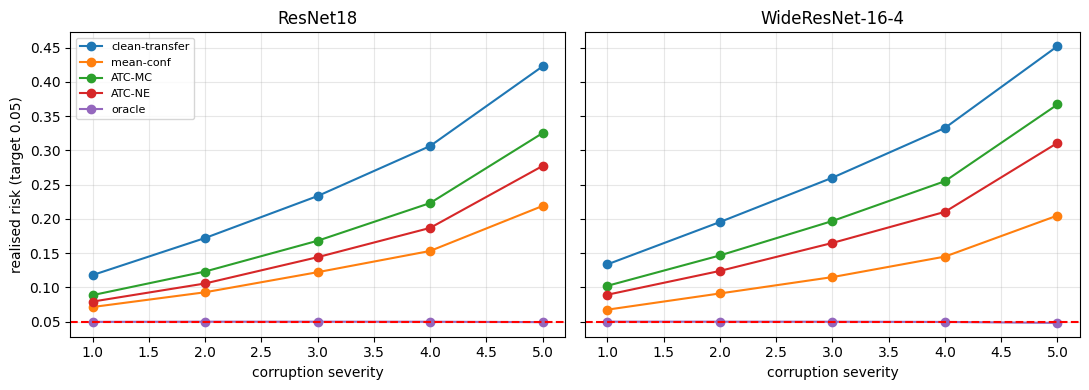

In [7]:
fig,ax=plt.subplots(1,2,figsize=(11,4),sharey=True)
for j,a in enumerate(("res","wrn")):
    for m,fn in METH.items():
        ys=[np.nanmean([rc(*P[(a,cc,sev)],fn(a,*P[(a,cc,sev)]))[0] for cc in STD15])
            for sev in range(1,6)]
        ax[j].plot(range(1,6),ys,"o-",label=m,lw=1.5)
    ax[j].axhline(TG,ls="--",c="r"); ax[j].set_xlabel("corruption severity")
    ax[j].set_title({"res":"ResNet18","wrn":"WideResNet-16-4"}[a]); ax[j].grid(alpha=.3)
ax[0].set_ylabel("realised risk (target 0.05)"); ax[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## What to check

1. Does the risk ordering of methods match across the two architectures?
2. Is coverage error still large and positive on `extra4`, the corruptions you
   never looked at? If yes, the result is not an artifact of tuning on the 15.
3. Does the label budget curve replicate on WideResNet?

If all three hold, stop experimenting and write.